<a href="https://colab.research.google.com/github/NikhilBsc/BscTraining/blob/main/mini_project(10_07_2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
hours = np.arange(1, 21)
scores = hours * 4.5 + np.random.normal(0, 2, size=20)
df = pd.DataFrame({
    "Hours_Studied": hours,
    "Exam_Score": scores
})
print(df.head())
print("Shape:", df.shape)

   Hours_Studied  Exam_Score
0              1    5.493428
1              2    8.723471
2              3   14.795377
3              4   21.046060
4              5   22.031693
Shape: (20, 2)


#Task 2

In [2]:
input_size = 1
hidden_size = 4
output_size = 1

W1 = np.random.randn(input_size, hidden_size)
b1 = np.random.randn(1, hidden_size)

W2 = np.random.randn(hidden_size, output_size)
b2 = np.random.randn(1, output_size)

print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (1, 4)
b1: (1, 4)
W2: (4, 1)
b2: (1, 1)


#Task 3

In [3]:
def relu(x):
    return np.maximum(0, x)
test = np.array([-3,-1,0,2,5])
print(relu(test))

[0 0 0 2 5]


#Task 4

In [4]:
def linear(x):
 return x

#Task 5

In [5]:
def forward(X, W1, b1, W2, b2):

    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    y_pred = linear(Z2)

    cache = (X, Z1, A1, Z2)

    return y_pred, cache

In [6]:
#test ----->>>
X_sample = df[['Hours_Studied']].values[:4]

preds, cache = forward(X_sample,W1,b1,W2,b2)

print(preds)

[[-0.56684525]
 [-1.44717061]
 [-2.32749597]
 [-3.20782132]]


#Task 6

In [7]:
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

In [8]:
#Testing
y_true = df[['Exam_Score']].values[:4]

loss = mse_loss(y_true, preds)

print("Loss:", loss)

Loss: 255.4031002817633


#Task 7


In [9]:
def backprop(X,y,W1,b1,W2,b2,cache):
    X, Z1, A1, Z2 = cache
    m = len(y)
    dZ2 = (2/m)*(Z2 - y)
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (Z1 > 0)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    grads = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return grads

In [10]:
#Testing
grads = backprop(X_sample,y_true,W1,b1,W2,b2,cache)

for k,v in grads.items():
    print(k, v.shape)

dW1 (1, 4)
db1 (1, 4)
dW2 (4, 1)
db2 (1, 1)


#Task 8

In [11]:
def update_params(W1,b1,W2,b2,grads,learning_rate):

    W1 -= learning_rate * grads['dW1']
    b1 -= learning_rate * grads['db1']

    W2 -= learning_rate * grads['dW2']
    b2 -= learning_rate * grads['db2']

    return W1,b1,W2,b2

#Task 9

In [12]:
def create_batches(X, y, batch_size=4):
    batches = []
    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]
        batches.append((X_batch, y_batch))

    return batches

In [13]:
#test
X = df[['Hours_Studied']].values
y = df[['Exam_Score']].values

batches = create_batches(X,y,4)

print("Number of batches:", len(batches))

Number of batches: 5


#Task 10 + Task 11

In [18]:
learning_rate = 0.001
epochs = 100
loss_history = []

for epoch in range(epochs):
    batches = create_batches(X,y,4)
    epoch_loss = 0
    for X_batch,y_batch in batches:
        y_pred, cache = forward(X_batch,W1,b1,W2,b2)
        loss = mse_loss(
            y_batch,
            y_pred
        )
        grads = backprop(
            X_batch,
            y_batch,
            W1,b1,
            W2,b2,
            cache
        )
        W1,b1,W2,b2 = update_params(
            W1,b1,W2,b2,
            grads,
            learning_rate
        )
        epoch_loss += loss
    avg_loss = epoch_loss / len(batches)
    loss_history.append(avg_loss)
    if (epoch+1)%10==0 or epoch==0:
        print(
            f"Epoch {epoch+1}: Loss={avg_loss:.4f}"
        )

Epoch 1: Loss=1668.1331
Epoch 10: Loss=971.6881
Epoch 20: Loss=62.9568
Epoch 30: Loss=2629.9208
Epoch 40: Loss=2264.4326
Epoch 50: Loss=1965.3067
Epoch 60: Loss=1720.4981
Epoch 70: Loss=1520.1473
Epoch 80: Loss=1356.1844
Epoch 90: Loss=1222.0038
Epoch 100: Loss=1112.1988


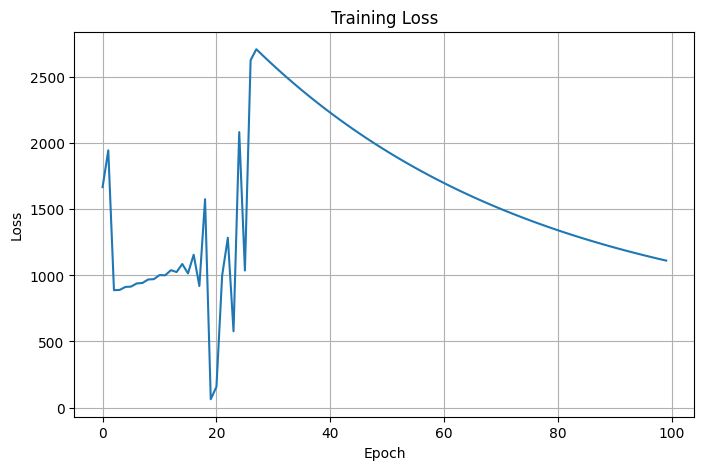

In [19]:
#task 12
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

In [20]:
#task 13
new_hours = np.array([[3],[11],[18]])
predictions,_ = forward(new_hours,W1,b1,W2,b2)
for h,p in zip(new_hours,predictions):
    print(f"Hours = {h[0]}, Predicted Score = {p[0]:.2f}")

Hours = 3, Predicted Score = 24.82
Hours = 11, Predicted Score = 24.82
Hours = 18, Predicted Score = 24.82


#optional task


In [14]:
def train_model(learning_rate):

    np.random.seed(42)

    W1 = np.random.randn(1,4)
    b1 = np.random.randn(1,4)

    W2 = np.random.randn(4,1)
    b2 = np.random.randn(1,1)

    loss_history = []

    epochs = 100

    for epoch in range(epochs):

        batches = create_batches(X, y, 4)

        epoch_loss = 0

        for X_batch, y_batch in batches:

            y_pred, cache = forward(X_batch,W1,b1,W2,b2)

            loss = mse_loss(y_batch,y_pred)

            grads = backprop(X_batch,y_batch,W1,b1,W2,b2,cache)

            W1,b1,W2,b2 = update_params(
                W1,b1,W2,b2,
                grads,
                learning_rate
            )

            epoch_loss += loss

        loss_history.append(
            epoch_loss / len(batches)
        )

    return loss_history

In [15]:
#training with 3 learning rates
loss_01 = train_model(0.01)

loss_001 = train_model(0.001)

loss_0001 = train_model(0.0001)

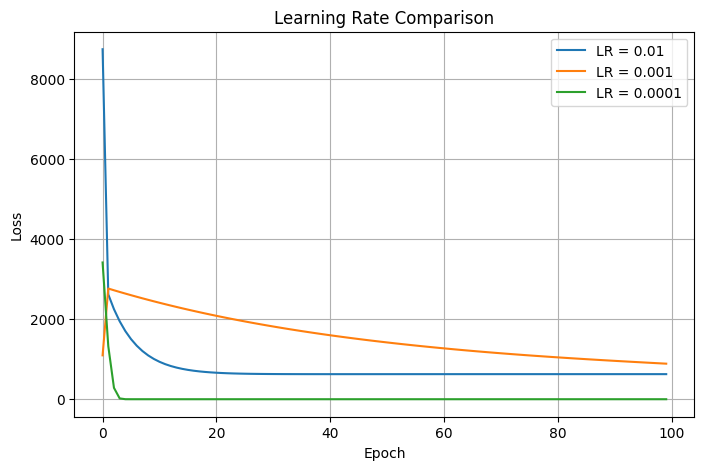

In [16]:
#plotting for curves
plt.figure(figsize=(8,5))

plt.plot(loss_01, label="LR = 0.01")

plt.plot(loss_001, label="LR = 0.001")

plt.plot(loss_0001, label="LR = 0.0001")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Learning Rate Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [17]:
new_hours = np.array([
    [3],
    [11],
    [18]
])

predictions,_ = forward(
    new_hours,
    W1,b1,
    W2,b2
)

for h,p in zip(new_hours,predictions):

    print(
        f"Hours = {h[0]}, Predicted Score = {p[0]:.2f}"
    )

Hours = 3, Predicted Score = -2.33
Hours = 11, Predicted Score = -9.37
Hours = 18, Predicted Score = -15.57
